In [1]:
# Imports
import utils_plotting
import pickle
import jax.numpy as jnp
from utils_inverse import _tree_to_jnp
import matplotlib.pyplot as plt
from utils_FaIR_JAX import generate_calib_data
import numpy as np
import utils_inverse
import jax
import glob
import xarray as xr

%load_ext autoreload
%autoreload 2

### Figure 1: Optimization pipeline overview

In [124]:
path_inverse = f'checkpoints/co2/inverse_gaussian_tier1_co2_only.pkl'
with open(path_inverse, "rb") as f:
  raw = pickle.load(f)
res = {
      "U_traj": [_tree_to_jnp(u) for u in raw["U_traj"]],
      "errors": jnp.asarray(raw["errors"], dtype=jnp.float32),
      "opt_state": _tree_to_jnp(raw["opt_state"]),
      "step_count": int(raw["step_count"]),
      "time_weights": None if raw["time_weights"] is None else _tree_to_jnp(raw["time_weights"]),
      "meta": raw.get("meta", {}),
      "preds_traj": raw["preds_traj"],
      "train_temp_traj": raw["train_temp_traj"],
  }

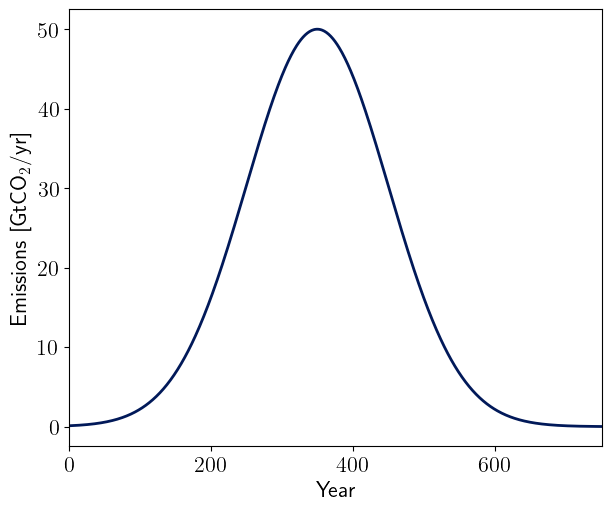

In [144]:
utils_plotting.plot_init(res, save=True)

In [149]:
agents = ['CO2']
emis_dict_calib_FaIR, emis_dict_calib_JAX, delT_dict_calib_FaIR, delT_dict_calib_JAX = generate_calib_data(agents)
group = ['historical','H-ext','M','ML','L','VLHO','VLLO-ext']
years = [np.arange(1750, 2024), np.arange(2024, 2501), np.arange(2024, 2151), np.arange(2024, 2151), np.arange(2024, 2151), np.arange(2024, 2151), np.arange(2024, 2501)]

tier1 = []
for i, scen in enumerate(group):
  tier1.append(emis_dict_calib_JAX[scen][0])

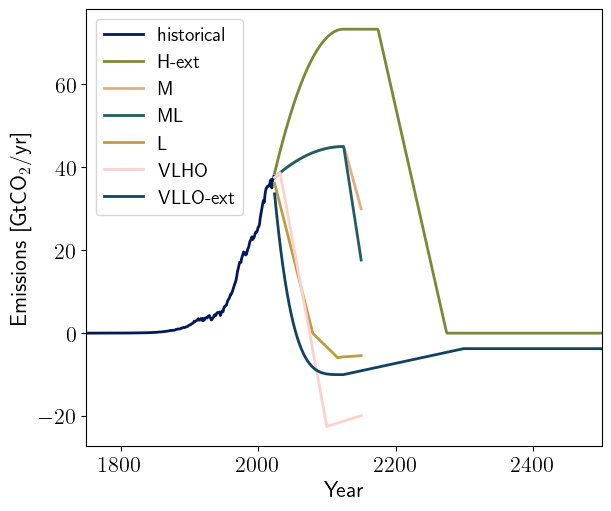

In [154]:
utils_plotting.plot_tier1(years, tier1, group, save=True)

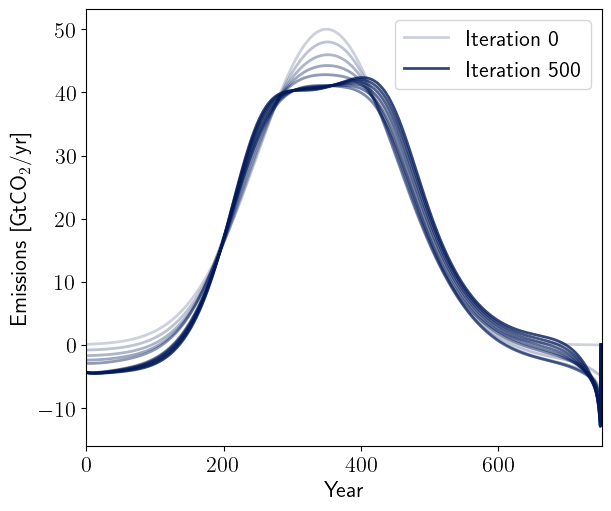

In [157]:
utils_plotting.plot_updates(res, save=True)

### Figure 2: Optimal emissions profile across different optimization targets

In [4]:
from utils_FaIR_JAX import generate_calib_data

agents = ['CO2']
emis_dict_calib_FaIR, emis_dict_calib_JAX, delT_dict_calib_FaIR, delT_dict_calib_JAX = generate_calib_data(agents)

plot_paths = ['checkpoints/co2/inverse_H-ext_constant_co2_only.pkl',
              'checkpoints/co2/inverse_constant_DECK_co2_only.pkl',
              'checkpoints/co2/inverse_constant_tier1_co2_only.pkl']

opt_emissions = []
for i, path in enumerate(plot_paths):
  with open(path, "rb") as f:
    raw = pickle.load(f)
  out = {
        "U_traj": [_tree_to_jnp(u) for u in raw["U_traj"]],
        "errors": jnp.asarray(raw["errors"], dtype=jnp.float32),
        "opt_state": _tree_to_jnp(raw["opt_state"]),
        "step_count": int(raw["step_count"]),
        "time_weights": None if raw["time_weights"] is None else _tree_to_jnp(raw["time_weights"]),
        "meta": raw.get("meta", {}),
        "preds_traj": raw["preds_traj"],
        "train_temp_traj": raw["train_temp_traj"],
    }
  opt_emissions.append([])
  for series in out['U_traj']:
    opt_emissions[i].append(series['CO2'])

In [5]:
agents = ['CO2']
emis_dict_calib_FaIR, emis_dict_calib_JAX, delT_dict_calib_FaIR, delT_dict_calib_JAX = generate_calib_data(agents)

path = 'checkpoints/co2/inverse_H-ext_constant_co2_only.pkl'
with open(path, "rb") as f:
  raw = pickle.load(f)
opt_results = {
      "U_traj": [_tree_to_jnp(u) for u in raw["U_traj"]],
      "errors": jnp.asarray(raw["errors"], dtype=jnp.float32),
      "opt_state": _tree_to_jnp(raw["opt_state"]),
      "step_count": int(raw["step_count"]),
      "time_weights": None if raw["time_weights"] is None else _tree_to_jnp(raw["time_weights"]),
      "meta": raw.get("meta", {}),
      "preds_traj": raw["preds_traj"],
      "train_temp_traj": raw["train_temp_traj"],
  }

opt_emissions, opt_temp = [], []
for series in opt_results['U_traj']:
  opt_emissions.append(series['CO2'])
for series in opt_results['train_temp_traj']:
  opt_temp.append(series[-1])

target_emissions = [emis_dict_calib_JAX['H-ext'][0].copy()]
years = np.arange(2024, 2501)

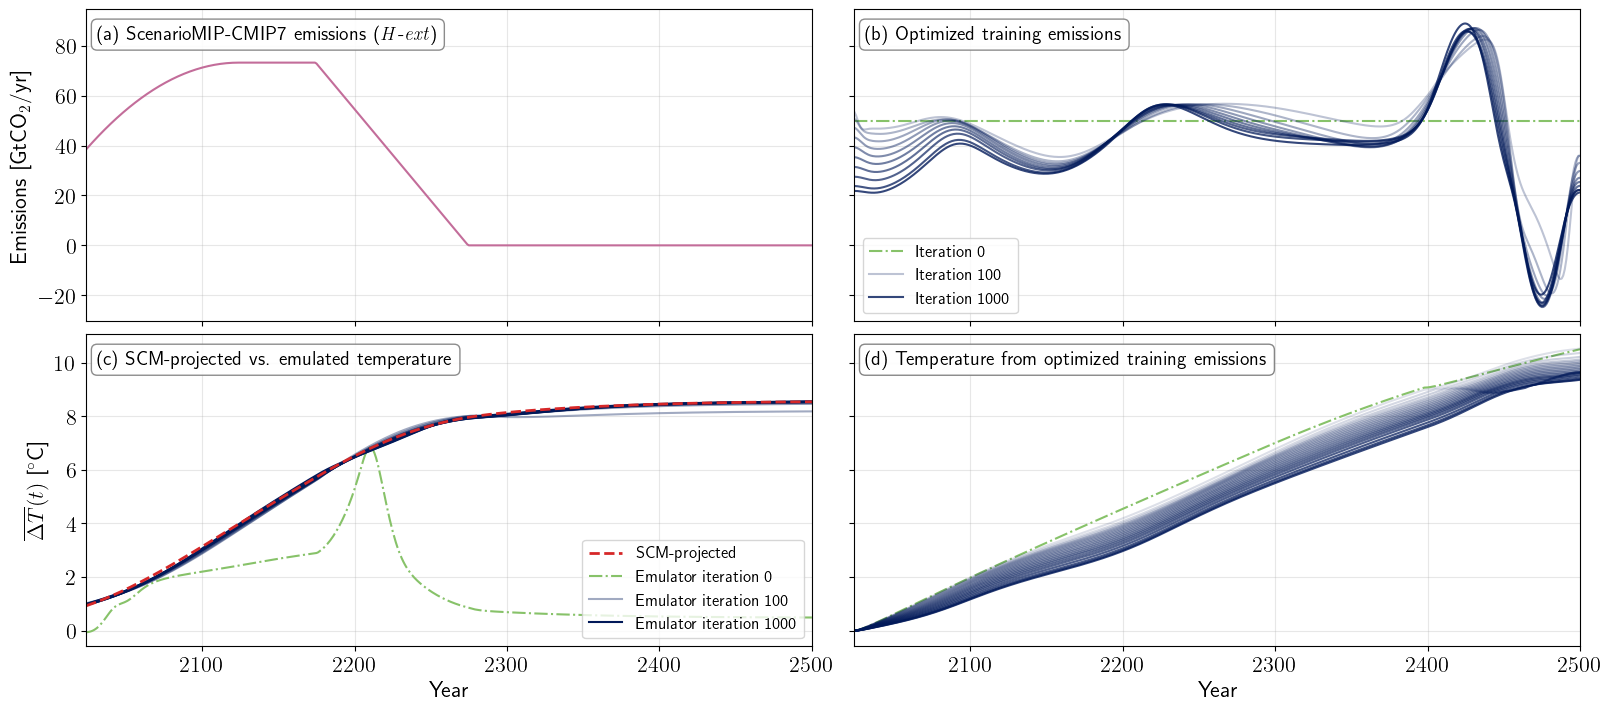

In [7]:
save = False
save_path = 'Figures/fig02_co2_example_ppt.pdf'
utils_plotting.plot_stacked_results(target_emissions, years, opt_emissions, opt_temp, opt_results, save=save, save_path=save_path)

In [2]:
agents = ['CO2']
emis_dict_calib_FaIR, emis_dict_calib_JAX, delT_dict_calib_FaIR, delT_dict_calib_JAX = generate_calib_data(agents)

path = 'checkpoints/co2/inverse_H-ext_constant_co2_only.pkl'
with open(path, "rb") as f:
  raw = pickle.load(f)
opt_results = {
      "U_traj": [_tree_to_jnp(u) for u in raw["U_traj"]],
      "errors": jnp.asarray(raw["errors"], dtype=jnp.float32),
      "opt_state": _tree_to_jnp(raw["opt_state"]),
      "step_count": int(raw["step_count"]),
      "time_weights": None if raw["time_weights"] is None else _tree_to_jnp(raw["time_weights"]),
      "meta": raw.get("meta", {}),
      "preds_traj": raw["preds_traj"],
      "train_temp_traj": raw["train_temp_traj"],
  }

opt_emissions, opt_temp = [], []
for series in opt_results['U_traj']:
  opt_emissions.append(series['CO2'])
for series in opt_results['train_temp_traj']:
  opt_temp.append(series[-1])

target_emissions = [emis_dict_calib_JAX['H-ext'][0].copy()]
years = np.arange(2024, 2501)

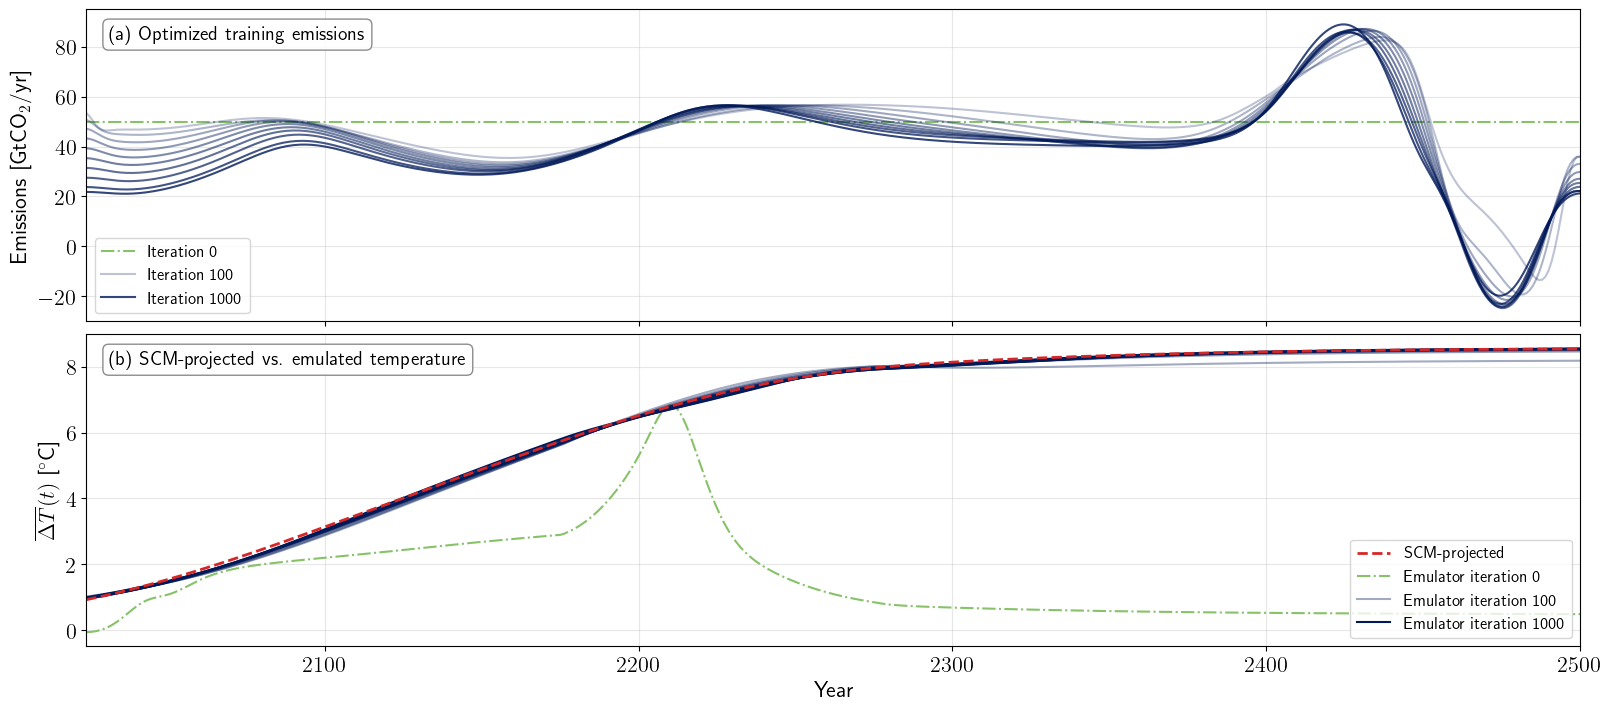

In [33]:
save = True
save_path = 'Figures/fig02_co2_example_ppt_4.pdf'
utils_plotting.plot_stacked_results_ppt(years, opt_emissions, opt_results, save=save, save_path=save_path)

### Figure 3: RMSE comparison across single-forcing experiments

In [29]:
agents = ['co2','ch4','n2o','Sulfur','BC']
results_inverse, results_baseline = [], []
for a in agents:
  path_inverse = f'checkpoints/{a}/inverse_constant_tier1_{a}_only.pkl'
  path_baseline = f'checkpoints/{a}/baseline_{a}_only.pkl'
  with open(path_inverse, "rb") as f:
    raw = pickle.load(f)
  out = {
        "U_traj": [_tree_to_jnp(u) for u in raw["U_traj"]],
        "errors": jnp.asarray(raw["errors"], dtype=jnp.float32),
        "opt_state": _tree_to_jnp(raw["opt_state"]),
        "step_count": int(raw["step_count"]),
        "time_weights": None if raw["time_weights"] is None else _tree_to_jnp(raw["time_weights"]),
        "meta": raw.get("meta", {}),
        "preds_traj": raw["preds_traj"],
        "train_temp_traj": raw["train_temp_traj"],
    }
  with open(path_baseline, "rb") as f:
    res_base = pickle.load(f)
  results_inverse.append(out)
  results_baseline.append(res_base['Tier 1']['mean'])

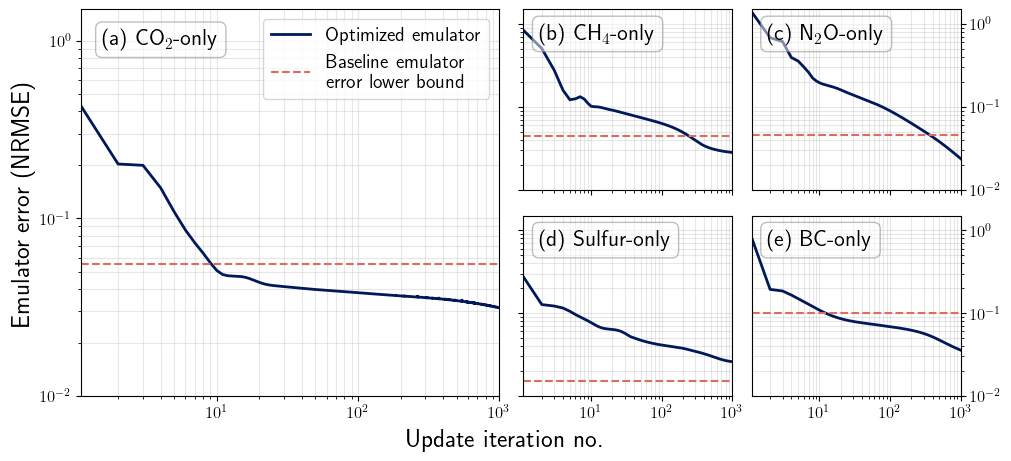

In [31]:
utils_plotting.plot_rmse_comparison_single(results_inverse, results_baseline, ['(a) CO$_2$','(b) CH$_4$','(c) N$_2$O','(d) Sulfur','(e) BC'], save=False)

### Figure 4: NRMSE comparison, multi-forcing w/ emissions data

In [8]:
agents = ['co2','ch4','n2o','Sulfur','BC']
path_inverse = f'checkpoints/multi/inverse_constant_tier1_all_agents_subset2.pkl'
path_baseline = f'checkpoints/multi/baseline_all_agents_subset.pkl'
with open(path_inverse, "rb") as f:
  raw = pickle.load(f)
out = {
      "U_traj": [_tree_to_jnp(u) for u in raw["U_traj"]],
      "errors": jnp.asarray(raw["errors"], dtype=jnp.float32),
      "opt_state": _tree_to_jnp(raw["opt_state"]),
      "step_count": int(raw["step_count"]),
      "time_weights": None if raw["time_weights"] is None else _tree_to_jnp(raw["time_weights"]),
      "meta": raw.get("meta", {}),
      "preds_traj": raw["preds_traj"],
      "train_temp_traj": raw["train_temp_traj"],
  }
with open(path_baseline, "rb") as f:
  res_base = pickle.load(f)

results_inverse = out
results_baseline = res_base['Tier 1']['mean']

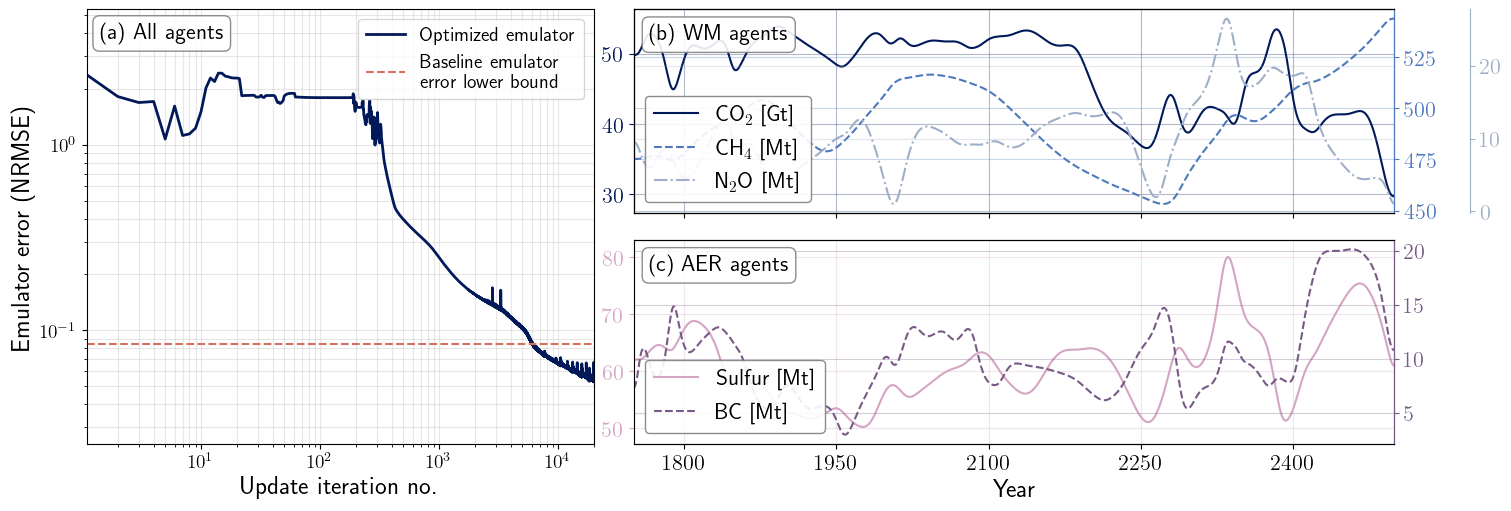

In [10]:
utils_plotting.plot_rmse_comparison_multi(results_inverse, results_baseline, save=False)

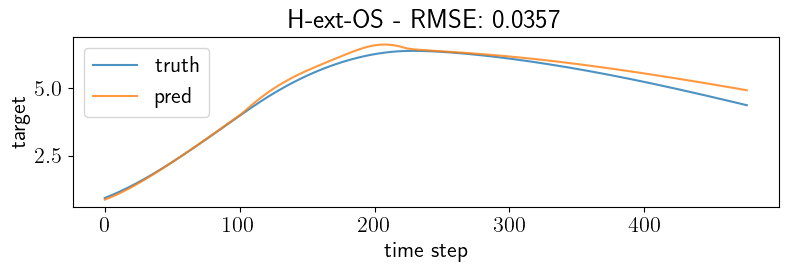

Getting gradient for historical...
	||grad BC||: 0.0
	||grad CH4||: 0.0
	||grad CO2||: 0.00019439701281953603
	||grad N2O||: 0.0
	||grad Sulfur||: 0.0


In [21]:
# Required to generate baseline parameters
agents        = ['CO2']       # Forcing agents included in temperatutre simulations
active_agents = ("CO2",)      # Forcing agents with active gradients (can differ from above)
hidden_sizes  = [16]          # Dimension of neural network emulator
idx_demo      = 1             # Index of scenario to plot
test_scen     = 'historical'  # Scenario to test backpropagation; gradient printed wrt this scenario
verbose       = False         # Flag to print RMSE values for test

# Generate initial parameters and test backpropagation
params0, emis_dict_train_JAX = utils_inverse.generate_init_params_and_train_data(agents,
                                                                                 active_agents,
                                                                                 test_scen,
                                                                                 hidden_sizes=hidden_sizes,
                                                                                 idx_demo=idx_demo,
                                                                                 verbose=verbose)

(eval_sets,
emis_dict_tier1_JAX,
emis_dict_tier2_JAX,
emis_dict_DECK_JAX,
emis_dict_CS3_JAX,
emis_dict_all_JAX) = utils_inverse.generate_eval_data(agents, CS3=True, DAMIP=False, GeoMIP=False)

In [26]:
import utils_inverse
training_paths = ['checkpoints/co2/inverse_constant_tier1_co2_only.pkl',
             'checkpoints/co2/inverse_constant_tier2_co2_only.pkl',
             'checkpoints/co2/inverse_constant_DECK_co2_only.pkl',
             'checkpoints/co2/inverse_constant_CS3_co2_only.pkl',
             'checkpoints/co2/inverse_constant_all_co2_only.pkl']
train_scenarios = ['Opt. Tier 1', 'Opt. Tier 2', 'Opt. DECK', 'Opt CS3', 'Opt. All']
optimal_results_co2 = utils_inverse.evaluate_optimal_emulator(
    training_paths=training_paths,
    train_scenarios=train_scenarios,
    eval_sets=eval_sets,
    params0=params0,
    active_agents=('CO2',),
    inactive_mode="zeros",
    historical_name="historical",
    key=jax.random.PRNGKey(0),
    K=400,
    lr=5e-2,
    weight_decay=1e-2,
)

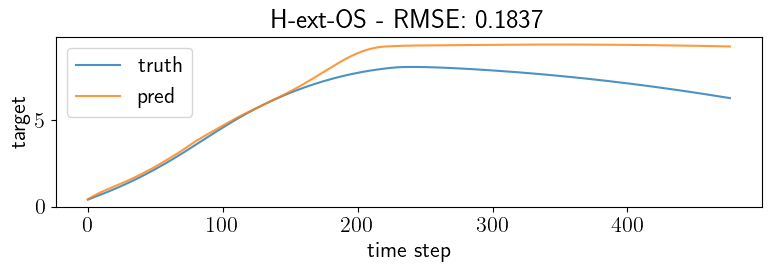

Getting gradient for historical...
	||grad BC||: 0.0025398300494998693
	||grad CH4||: 3.985055809607729e-05
	||grad CO2||: 0.0002717208117246628
	||grad N2O||: 0.001030437182635069
	||grad Sulfur||: 6.44300744170323e-05


In [21]:
# Required to generate baseline parameters
agents        = ['CO2','CH4',
                 'N2O','Sulfur',
                 'BC']          # Forcing agents included in temperatutre simulations
active_agents = ('CO2','CH4',
                 'N2O','Sulfur',
                 'BC')          # Forcing agents with active gradients (can differ from above)
hidden_sizes  = [16]            # Dimension of neural network emulator
idx_demo      = 1               # Index of scenario to plot
test_scen     = 'historical'    # Scenario to test backpropagation; gradient printed wrt this scenario
verbose       = False           # Flag to print RMSE values for test

# Generate initial parameters and test backpropagation
params0, emis_dict_train_JAX = utils_inverse.generate_init_params_and_train_data(agents,
                                                                                 active_agents,
                                                                                 test_scen,
                                                                                 hidden_sizes=hidden_sizes,
                                                                                 idx_demo=idx_demo,
                                                                                 verbose=verbose)

# Generate data for emulator evaluation
(eval_sets,
emis_dict_tier1_JAX,
emis_dict_tier2_JAX,
emis_dict_DECK_JAX,
emis_dict_CS3_JAX,
#emis_dict_DAMIP_JAX,
#emis_dict_GeoMIP_JAX,
emis_dict_all_JAX) = utils_inverse.generate_eval_data(agents, CS3=True, DAMIP=False, GeoMIP=False)

In [22]:
training_paths = ['checkpoints/multi/inverse_constant_tier1_all_agents_subset2.pkl',
                  'checkpoints/multi/inverse_constant_tier2_all_agents_subset.pkl',
                  'checkpoints/multi/inverse_constant_DECK_all_agents_subset.pkl',
                  'checkpoints/multi/inverse_constant_CS3_all_agents_subset.pkl',
                  'checkpoints/multi/inverse_constant_all_all_agents_subset.pkl']
train_scenarios = ['Opt. Tier 1', 'Opt. Tier 2', 'Opt. DECK', 'Opt. CS3', 'Opt. All']
optimal_results_all = utils_inverse.evaluate_optimal_emulator(
    training_paths=training_paths,
    train_scenarios=train_scenarios,
    eval_sets=eval_sets,
    params0=params0,
    active_agents=('CO2','CH4','N2O','Sulfur','BC'),
    inactive_mode="zeros",
    historical_name="historical",
    key=jax.random.PRNGKey(0),
    K=400,
    lr=5e-2,
    weight_decay=1e-2,
)

In [23]:
save_path = 'data/plotting/optimal_all_agents_subset.pkl'
with open(save_path, "wb") as f:
  pickle.dump(optimal_results_all, f)

In [2]:
baseline_path_co2 = 'data/plotting/baseline_co2_only.pkl'
with open(baseline_path_co2, 'rb') as file:
    baseline_results_co2 = pickle.load(file)

optimal_path_co2 = 'data/plotting/optimal_co2_only.pkl'
with open(optimal_path_co2, 'rb') as file:
    optimal_results_co2 = pickle.load(file)


In [3]:
baseline_path_all = 'data/plotting/baseline_all_agents_subset.pkl'
with open(baseline_path_all, 'rb') as file:
    baseline_results_all = pickle.load(file)

optimal_path_all = 'data/plotting/optimal_all_agents_subset.pkl'
with open(optimal_path_all, 'rb') as file:
    optimal_results_all = pickle.load(file)

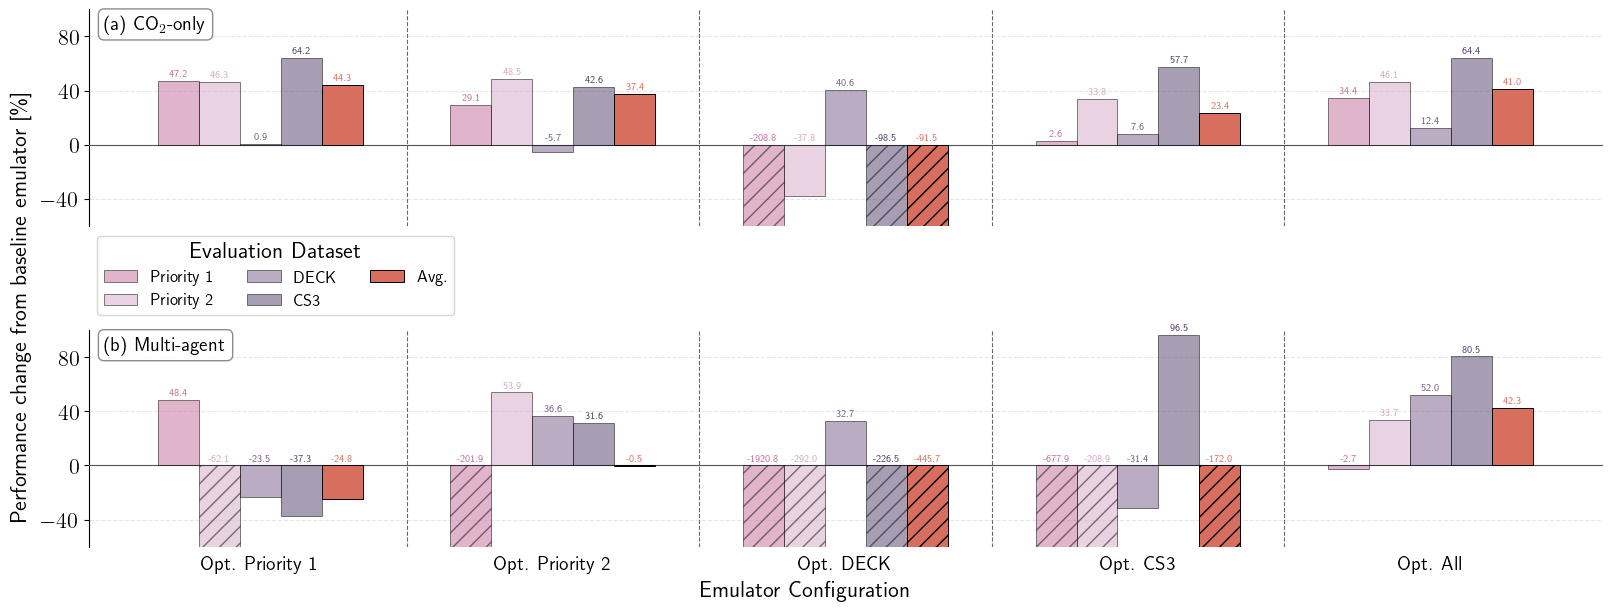

In [46]:
baseline_results_list = [baseline_results_co2, baseline_results_all]
optimal_results_list = [optimal_results_co2, optimal_results_all]
weights = [7, 5, 2, 2]
figname = 'performance_summary'
train_scenarios = ['Opt. Tier 1', 'Opt. Tier 2', 'Opt. DECK', 'Opt. CS3', 'Opt. All']
test_scenarios = ['Tier 1', 'Tier 2', 'DECK', 'CS3']
x_labels = ['Opt. Priority 1', 'Opt. Priority 2', 'Opt. DECK', 'Opt. CS3', 'Opt. All']
leg_labels = ['Priority 1', 'Priority 2', 'DECK', 'CS3']
utils_plotting.plot_vertical_stacked_bars(baseline_results_list,
                               optimal_results_list,
                               train_scenarios,
                               test_scenarios,
                               x_labels,
                               leg_labels,
                               weights,
                               titles=None,
                               save=False,
                               figname=figname)

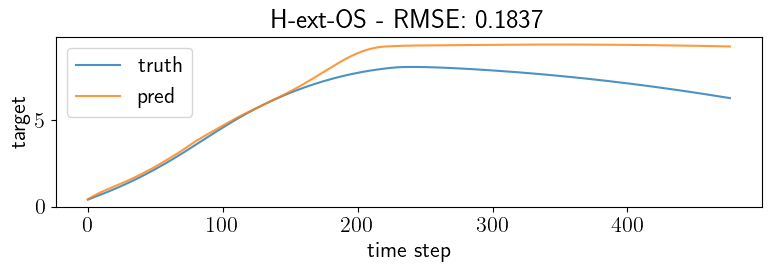

Getting gradient for historical...
	||grad BC||: 0.0025398300494998693
	||grad CH4||: 3.985055809607729e-05
	||grad CO2||: 0.0002717208117246628
	||grad N2O||: 0.001030437182635069
	||grad Sulfur||: 6.44300744170323e-05


In [11]:
# Required to generate baseline parameters
agents        = ['CO2','CH4',
                 'N2O','Sulfur',
                 'BC']          # Forcing agents included in temperatutre simulations
active_agents = ('CO2','CH4',
                 'N2O','Sulfur',
                 'BC')          # Forcing agents with active gradients (can differ from above)
hidden_sizes  = [16]            # Dimension of neural network emulator
idx_demo      = 1               # Index of scenario to plot
test_scen     = 'historical'    # Scenario to test backpropagation; gradient printed wrt this scenario
verbose       = False           # Flag to print RMSE values for test

# Generate initial parameters and test backpropagation
params0, emis_dict_train_JAX = utils_inverse.generate_init_params_and_train_data(agents,
                                                                                 active_agents,
                                                                                 test_scen,
                                                                                 hidden_sizes=hidden_sizes,
                                                                                 idx_demo=idx_demo,
                                                                                 verbose=verbose)

(eval_sets_ind_effects,
emis_dict_tier1_JAX,
emis_dict_tier2_JAX,
emis_dict_DECK_JAX,
emis_dict_DAMIP_JAX,
emis_dict_GeoMIP_JAX,
emis_dict_CS3_JAX,
emis_dict_all_JAX) = utils_inverse.generate_eval_data(agents, CS3=True, DAMIP=True, GeoMIP=True)

# Create baseline emulator
baseline_results, y_hat_baseline, y_true_ind_effects = utils_inverse.generate_and_eval_baseline_emulator(emis_dict_tier1_JAX,
                                                                                                            eval_sets_ind_effects, save_path=None,
                                                                                                            verbose=verbose, hidden_sizes=hidden_sizes)

In [12]:
training_paths_ind_effects = ['checkpoints/multi/inverse_constant_tier1_all_agents_subset2.pkl',
                              'checkpoints/multi/inverse_constant_DAMIP_all_agents.pkl',
                              'checkpoints/multi/inverse_constant_GeoMIP_all_agents.pkl',
                              'checkpoints/multi/inverse_constant_all_all_agents.pkl']
train_scenarios_ind_effects = ['Opt. Tier 1', 'Opt. DAMIP', 'Opt. GeoMIP', 'Opt. All']
optimal_results_ind_effects, y_hat_ind_effects = utils_inverse.evaluate_optimal_emulator(
    training_paths=training_paths_ind_effects,
    train_scenarios=train_scenarios_ind_effects,
    eval_sets=eval_sets_ind_effects,
    params0=params0,
    active_agents=('CO2','CH4','N2O','Sulfur','BC'),
    inactive_mode="zeros",
    historical_name="historical",
    key=jax.random.PRNGKey(0),
    K=400,
    lr=5e-2,
    weight_decay=1e-2,
    ind_effects=True
)

In [13]:
save_path = 'data/plotting/y_hat_baseline_ind_effects.pkl'
with open(save_path, "wb") as f:
  pickle.dump(y_hat_baseline, f)

save_path = 'data/plotting/y_true_ind_effects.pkl'
with open(save_path, "wb") as f:
  pickle.dump(y_true_ind_effects, f)

save_path = 'data/plotting/y_hat_ind_effects.pkl'
with open(save_path, "wb") as f:
  pickle.dump(y_hat_ind_effects, f)

In [11]:
path = 'data/plotting/y_hat_baseline_ind_effects.pkl'
with open(path, 'rb') as file:
  y_hat_baseline = pickle.load(file)

path = 'data/plotting/y_true_ind_effects.pkl'
with open(path, 'rb') as file:
  y_true_ind_effects = pickle.load(file)

path = 'data/plotting/y_hat_ind_effects.pkl'
with open(path, 'rb') as file:
  y_hat_ind_effects = pickle.load(file)

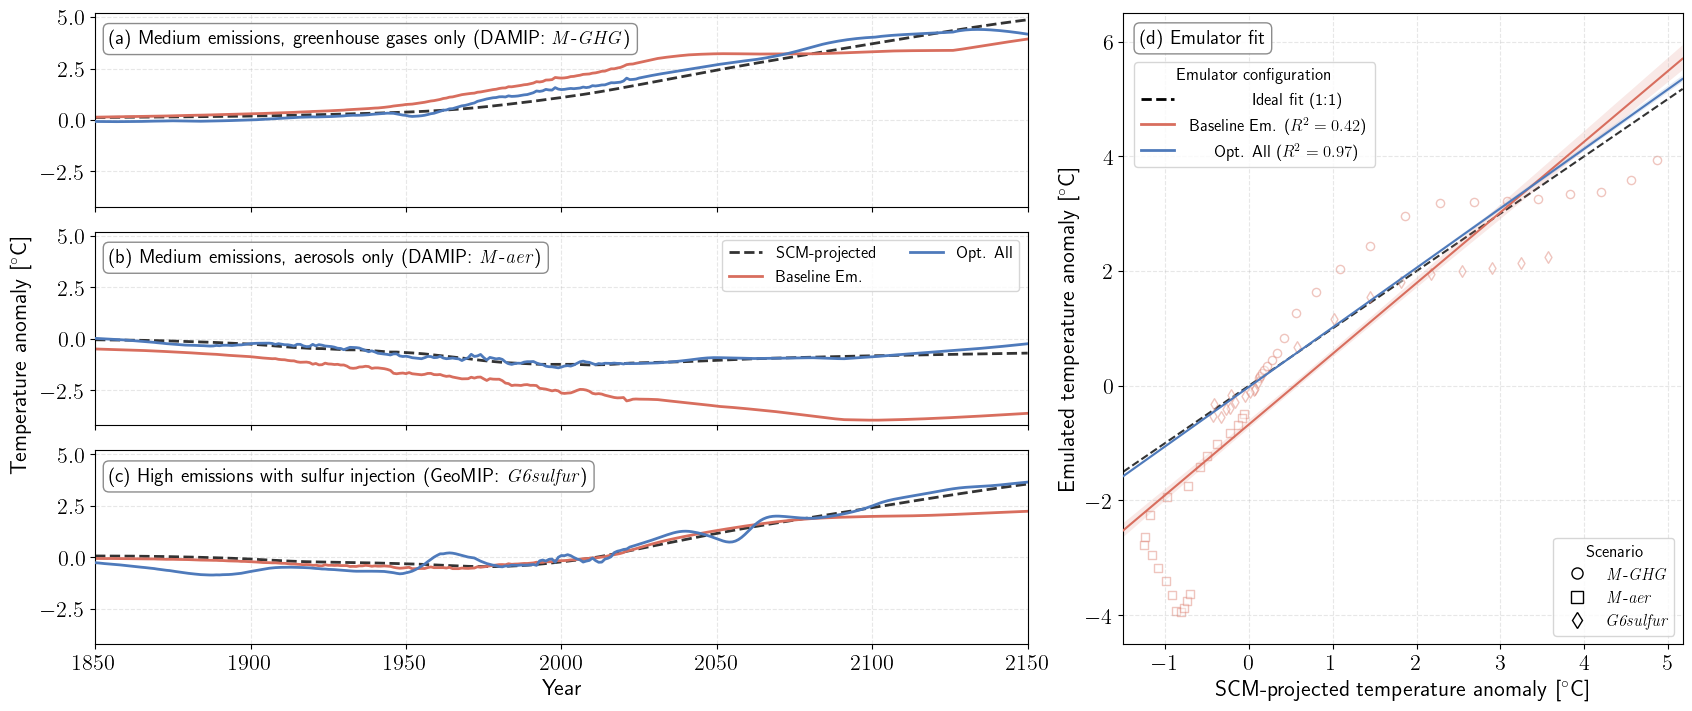

In [67]:
from cmcrameri import cm
from sklearn.metrics import r2_score
from collections import defaultdict
import numpy as np
from matplotlib.lines import Line2D
import seaborn as sns

training_paths_ind_effects = ['checkpoints/multi/inverse_constant_tier1_all_agents_subset2.pkl',
                              'checkpoints/multi/inverse_constant_DAMIP_all_agents.pkl',
                              'checkpoints/multi/inverse_constant_GeoMIP_all_agents.pkl',
                              'checkpoints/multi/inverse_constant_all_all_agents.pkl']
train_scenarios_ind_effects = ['Opt. Tier 1', 'Opt. DAMIP', 'Opt. GeoMIP', 'Opt. All']

ppt = True
i_ppt = 0

layout = [
        ["Left1", "Left1", "Left1", "Left1", "Left1", "Right", "Right", "Right"],
        ["Left2", "Left2", "Left2", "Left2", "Left2", "Right", "Right", "Right"],
        ["Left3", "Left3", "Left3", "Left3", "Left3", "Right", "Right", "Right"],
    ]

plot_map = {"Left1":"M_GHG", "Left2":"M_AER", "Left3":"G6sulfur"}
color_map = {'Opt. Tier 1':cm.actonS(2), 'Opt. DAMIP':cm.actonS(4), 'Opt. GeoMIP': cm.actonS(6), 'Opt. All':cm.osloS(2)}
labels = [r"(a) Medium emissions, greenhouse gases only (DAMIP: $\it{M}$-$\it{GHG}$)",
          r"(b) Medium emissions, aerosols only (DAMIP: $\it{M}$-$\it{aer}$)",
          r"(c) High emissions with sulfur injection (GeoMIP: $\it{G6sulfur}$)"]
plot_len = len(y_true_ind_effects["All"]["M_GHG"])
x_vals = np.arange(1850, 2151)

if ppt:
    figsize = (16.81, 7)
else:
    figsize = (17.8, 7)

fig, ax_dict = plt.subplot_mosaic(
    layout,
    figsize=figsize,
    constrained_layout=True,
    gridspec_kw={"wspace": 0.001, "hspace": 0.001}
)

for j, ax_label in enumerate(plot_map):
    ax_plot = ax_dict[ax_label]
    scen_plot = plot_map[ax_label]

    ax_plot.plot(x_vals, y_true_ind_effects['All'][scen_plot][100:plot_len], label='SCM-projected', c='black', ls='--', lw=2, alpha = 0.8)
    ax_plot.plot(x_vals, y_hat_baseline['All'][scen_plot][100:plot_len], label='Baseline Em.', lw=2, ls="-", c=cm.lipariS(5))

    for i, train in enumerate(reversed(train_scenarios_ind_effects)):
        train_label = train
        if train in ['Opt. Tier 2','Opt. DECK', 'Opt. CS3']:
            continue
        if train not in ['Opt. All']:
            continue
        alpha = 0.6
        zorder = 0
        ls = (0, (5, 4))
        if train == 'Opt. All':
            alpha = 1
            zorder = 10
            ls = '-'
        elif train == 'Opt. Tier 1':
            train_label = 'Opt. Prio. 1'
        ax_plot.plot(x_vals, y_hat_ind_effects[train]['All'][scen_plot][100:plot_len], alpha=alpha, label=train_label, zorder=zorder, lw=2, ls=ls, color=color_map[train])

    if ax_label != "Left3":
        ax_plot.sharex(ax_dict["Left3"])
        ax_plot.sharey(ax_dict["Left3"])
        ax_plot.tick_params(labelbottom=False)

    ax_plot.grid(linestyle='--', alpha=0.3, zorder=0)

    ax_plot.text(
            0.015, 0.915, labels[j], transform=ax_plot.transAxes,
            ha="left", va="top", fontsize=14, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.9)
          )
    ax_plot.set_ylim([-4.2, 5.2])

ax_plot.set_xlim([1850, 2150])
ax_plot.set_xlabel("Year")

ax_dict["Left2"].legend(ncol=2,
                  frameon=True,
                  fancybox=True,
                  framealpha=0.8,
                  facecolor='white',
                  edgecolor='#cccccc',
                  fontsize=12)

fig.supylabel(r'Temperature anomaly [$^\circ$C]', fontsize=16)

ax_plot = ax_dict['Right']

scenario_legend_handles = {}
marker_legend_handles = []
scenarios = ["M_GHG","M_AER","G6sulfur"]
model_performance = defaultdict(lambda: {'true': [], 'pred': [], 'color': None})

step = 15
size = 35
markers = ['o','s','d']
base_color = cm.lipariS(5)

for j, scen_plot in enumerate(scenarios):
    y_true = y_true_ind_effects['All'][scen_plot][100:plot_len]
    y_pred_base = y_hat_baseline['All'][scen_plot][100:plot_len]
    ax_plot.scatter(y_true[::step], y_pred_base[::step],
                    marker=markers[j], color=base_color, s=size,
                    facecolor='white', linewidths=1, alpha=0.4)

    model_performance['Baseline Em.']['true'].extend(y_true)
    model_performance['Baseline Em.']['pred'].extend(y_pred_base)
    model_performance['Baseline Em.']['color'] = base_color

    for i, train in enumerate(reversed(train_scenarios_ind_effects)):
            if train in ['Opt. Tier 2','Opt. DECK', 'Opt. CS3']:
                continue
            y_pred = y_hat_ind_effects[train]['All'][scen_plot][100:plot_len]

            #ax_plot.scatter(y_true[::step], y_pred[::step],
            #                color=color_map[train], marker=markers[j],
            #                s=size, facecolor='white', linewidths=1,
            #                alpha=0.4)

            model_performance[train]['true'].extend(y_true)
            model_performance[train]['pred'].extend(y_pred)
            model_performance[train]['color'] = color_map[train]

emulator_handles = [Line2D([0], [0], ls='--', color='k', lw=2, label=f"Ideal fit (1:1)")]
for name, data in model_performance.items():
    markeredgewidth = 1
    ls = (0, (5, 4))
    if name not in ['Baseline Em.','Opt. All']:
        continue
    if name == 'Opt. All' or name == 'Baseline Em.':
        markeredgewidth = 1.75
        ls = '-'
    elif name == 'Opt. Tier 1':
        name = 'Opt. Prio. 1'
    sns.regplot(
        x=np.array(data['true']),
        y=np.array(data['pred']),
        scatter=False,
        ci=95,
        color=data['color'],
        ax=ax_plot,
        truncate=False,
        line_kws={'linewidth': 1.5, 'zorder': 11, 'linestyle':ls}
    )
    score = r2_score(data['true'], data['pred'])
    handle = Line2D([0], [0], ls=ls, color=data['color'], lw=2, label=f"{name} ($R^2={score:.2f}$)")
    emulator_handles.append(handle)

scenario_handles = []
scen_labels = [r'$\it{M}$-$\it{GHG}$',r'$\it{M}$-$\it{aer}$',r'$\it{G6sulfur}$']
for marker, label in zip(markers, scen_labels):
    handle = Line2D([0], [0], marker=marker, color='w', label=label,
                    markerfacecolor='white', markeredgecolor='k', markersize=8)
    scenario_handles.append(handle)

scen_legend = ax_plot.legend(handles=scenario_handles, loc='lower right', title='Scenario', fontsize=12, title_fontsize=12)
ax_plot.add_artist(scen_legend)

emu_legend = ax_plot.legend(handles=emulator_handles,
                            loc='upper left', fontsize=12,
                            bbox_to_anchor=(0.019893604239317852,
                                            0.6345526951619422,
                                            0.43059349211779896,
                                            0.2872407910360216),
                            title='Emulator configuration',
                            mode='expand',
                            title_fontsize=12,
                            borderaxespad=0)
shift = [65, 2, 26, 0, 3, 6]
for i, text in enumerate(emu_legend.get_texts()):
    text.set_horizontalalignment('right')
    text.set_x(shift[i])

ax_plot.grid(linestyle='--', alpha=0.3, zorder=0)
ax_plot.set_ylabel(r'Emulated temperature anomaly [$^\circ$C]')
ax_plot.set_xlabel(r'SCM-projected temperature anomaly [$^\circ$C]')
ax_plot.axline((0, 0), slope=1, color='black', alpha=0.8, linestyle='--', linewidth=1.5, zorder=0)
ax_plot.set_xlim([-1.5, 5.175])
ax_plot.set_ylim([-4.5, 6.5])
#ax_plot.set_aspect('equal')
final_handles = list(scenario_legend_handles.values()) + marker_legend_handles

ax_plot.text(
            0.03, 0.975, '(d) Emulator fit', transform=ax_plot.transAxes,
            ha="left", va="top", fontsize=14, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.9)
          )

plt.savefig('Figures/individual_effects_ppt4.pdf')

In [48]:
bbox = emu_legend.get_window_extent()
bbox_axes = bbox.transformed(ax_plot.transAxes.inverted())

In [50]:
bbox_axes.width

np.float64(0.40080628363916304)

In [34]:
path = 'data/plotting/baseline_co2_only_MESM.pkl'
with open(path, 'rb') as file:
  baseline_MESM = pickle.load(file)

opt_MESM = []
ICs = ['constant','sine','both']
for IC in ICs:
  path = f'data/plotting/optimal_co2_only_MESM_{IC}.pkl'
  with open(path, 'rb') as file:
    opt_MESM.append(pickle.load(file))

In [46]:
scenario_keys = ['historical', 'H-ext', 'M', 'ML', 'L', 'VLLO-ext', 'VLHO',
                 'H-ext-OS', 'M-ext', 'ML-ext', 'L-ext', 'VLHO-ext',
                 '2xCO2', '1pctCO2',
                 'AA', 'CT']
legend_labels = ['Const.','Sine','Both']
scenario_labels = [r'$\it{historical}$', r'$\it{H}$-$\it{ext}$', r'$\it{M}$', r'$\it{ML}$',r'$\it{L}$', r'$\it{VLLO}$-$\it{ext}$', r'$\it{VLHO}$',
                   r'$\it{H}$-$\it{ext}$-$\it{OS}$', r'$\it{M}$-$\it{ext}$', r'$\it{ML}$-$\it{ext}$', r'$\it{L}$-$\it{ext}$', r'$\it{VLHO}$-$\it{ext}$',
                   r'$\it{abrupt}$-$\it{2xCO2}$', r'$\it{1pctCO2}$',
                   r'$\it{AA}$', r'$\it{CT}$']

In [36]:
ICs = ['constant','sine']
co2_data = []
for IC in ICs:
  opt_path = f"checkpoints/co2/inverse_{IC}_all_co2_only_MESM.pkl"
  with open(opt_path, "rb") as f:
      res = pickle.load(f)
  co2_data.append(res['U_traj'][-1]['CO2'])

In [42]:
lat0, latf = -88, 88
output_dim = 46
lat_coords = np.linspace(lat0, latf, output_dim)
weights = np.cos(np.deg2rad(lat_coords))
weights = np.maximum(weights, 1e-6)
weights = weights / np.sum(weights)

experiment_labels = ['optimized']
scenarios = {'optimized':['opt_all','opt_all_sine']}
global_mean_temp = []
for exp_label in experiment_labels:
  for scen in scenarios[exp_label]:
    path = f'data/MESM/emis_driven/zonal_data/{exp_label}/ZONALANN.{scen}*.nc'
    files = sorted(glob.glob(path))
    ds = xr.open_mfdataset(path, combine='nested', concat_dim='member', parallel=True, coords='minimal')
    ensemble_mean = ds['DT2M'].mean(dim='member')
    ensemble_mean_np = ensemble_mean.compute().values

    global_mean_temp.append(np.average(ensemble_mean_np, weights=weights, axis=1))

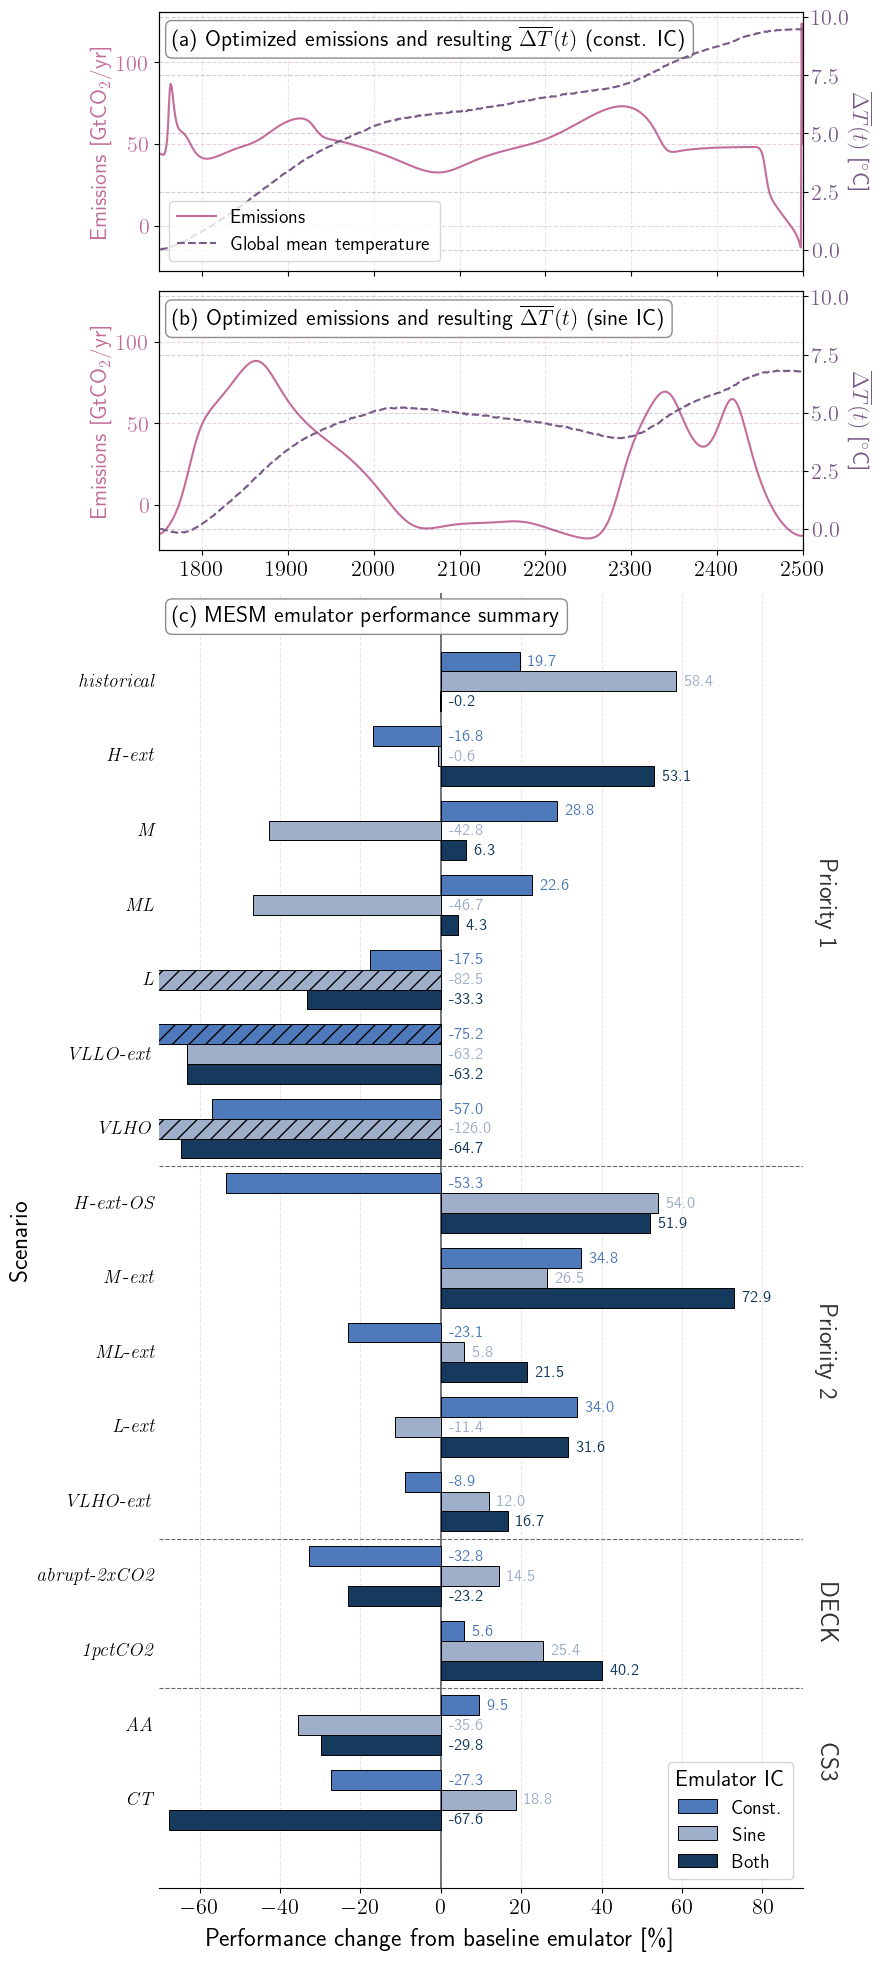

In [73]:
separator_indices = [6, 11, 13]
group_labels = ['Priority 1', 'Prioriity 2', 'DECK', 'CS3']
utils_plotting.plot_scenario_difference_bars2(baseline_MESM,
                                             opt_MESM,
                                             scenario_keys,
                                             legend_labels,
                                             co2_data,
                                             global_mean_temp,
                                             scenario_labels,
                                             separator_indices,
                                             group_labels,
                                             save=True,
                                             figname='fig07_emic_summary')